# **Laptop Specifications Data Analysis**

# Import Required Libraries

In [10]:
# importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style

plt.style.use("default")
sns.set_palette("Set2")

# Load Dataset

In [11]:
# Load Dataset
df = pd.read_csv("/content/laptop.csv")

print("Dataset Loaded Successfully")
print("-" * 50)

Dataset Loaded Successfully
--------------------------------------------------


# Basic Data Understanding

In [12]:
# Understanding the basic data

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (3976, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3976 entries, 0 to 3975
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       3976 non-null   int64  
 1   Brand            3976 non-null   object 
 2   Name             3976 non-null   object 
 3   Price            3976 non-null   int64  
 4   Processor_Name   3976 non-null   object 
 5   Processor_Brand  3976 non-null   object 
 6   RAM_Expandable   3976 non-null   object 
 7   RAM              3976 non-null   int64  
 8   RAM_TYPE         3976 non-null   object 
 9   Ghz              3976 non-null   object 
 10  Display_type     3976 non-null   object 
 11  Display          3976 non-null   object 
 12  GPU              3968 non-null   object 
 13  GPU_Brand        3972 non-null   object 
 14  SSD              3976 non-null   object 
 15  HDD              3976 non-null   object 
 16  Adapter          39

# Data Cleaning & Preprocessing

In [13]:
# Check missing values

print("\nMissing Values:")
print(df.isnull().sum())


# Fill missing values

df['SSD'].fillna(0, inplace=True)
df['HDD'].fillna(0, inplace=True)
df['GPU'].fillna("None", inplace=True)
df['GPU_Brand'].fillna("None", inplace=True)


# Convert data types

df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


df['RAM'] = (
    df['RAM']
    .astype(str)
    .str.extract(r'(\d+)')
)
df['RAM'] = pd.to_numeric(df['RAM'], errors='coerce')
df['RAM'].fillna(df['RAM'].median(), inplace=True)


df['Battery_Life'] = (
    df['Battery_Life']
    .astype(str)
    .str.lower()
    .str.replace("upto", "", regex=False)
    .str.replace("up to", "", regex=False)
    .str.replace("hrs", "", regex=False)
    .str.replace("hours", "", regex=False)
    .str.replace("battery life", "", regex=False)
    .str.replace(" ", "", regex=False)
)
df['Battery_Life'] = pd.to_numeric(df['Battery_Life'], errors='coerce')
df['Battery_Life'].fillna(df['Battery_Life'].median(), inplace=True)



# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nData Cleaning Completed")
print("-" * 50)



Missing Values:
Unnamed: 0         0
Brand              0
Name               0
Price              0
Processor_Name     0
Processor_Brand    0
RAM_Expandable     0
RAM                0
RAM_TYPE           0
Ghz                0
Display_type       0
Display            0
GPU                8
GPU_Brand          4
SSD                0
HDD                0
Adapter            0
Battery_Life       0
dtype: int64

Data Cleaning Completed
--------------------------------------------------


/tmp/ipython-input-2995995500.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SSD'].fillna(0, inplace=True)
/tmp/ipython-input-2995995500.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method

# Exploratory Data Analysis (EDA)


Top 10 Brands:
Brand
ASUS         989
Lenovo       811
HP           803
Dell         420
Acer         322
MSI          316
Samsung       61
Apple         49
Infinix       39
Microsoft     34
Name: count, dtype: int64


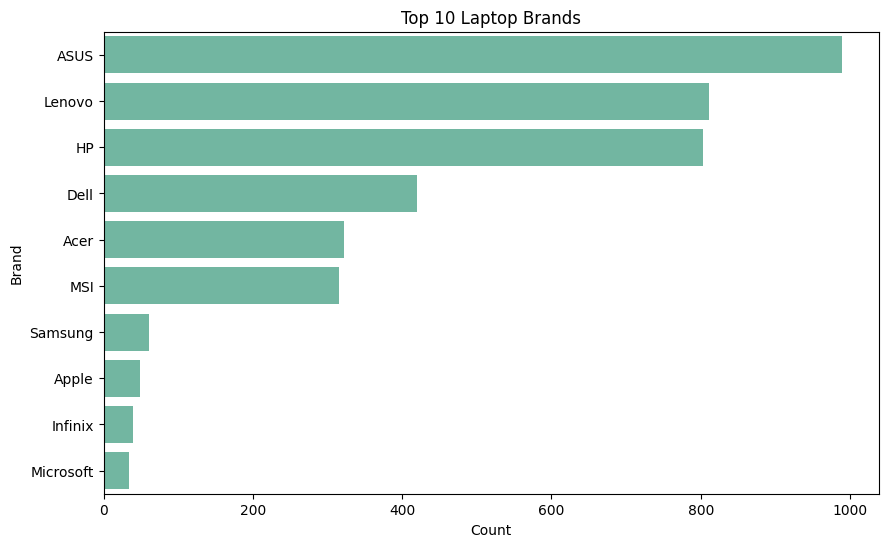

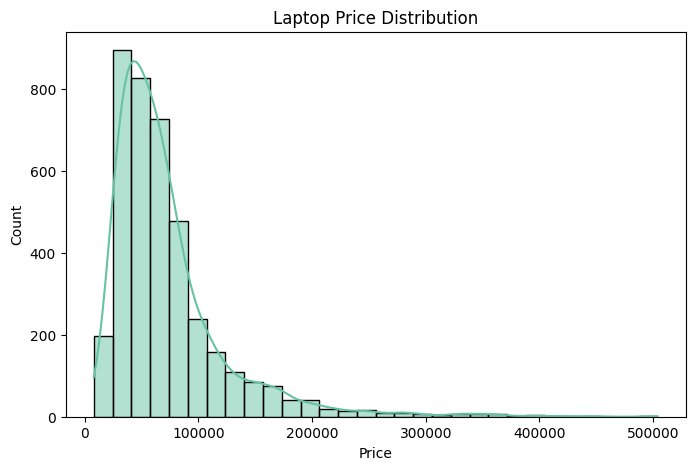

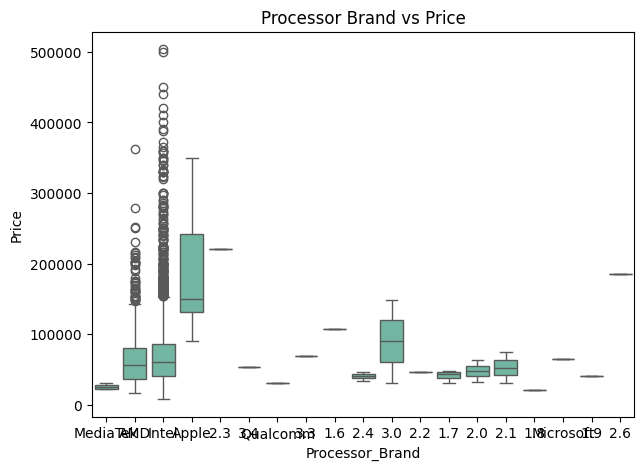

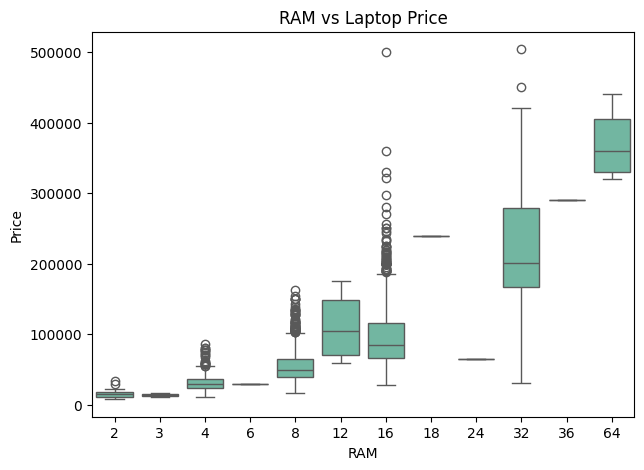

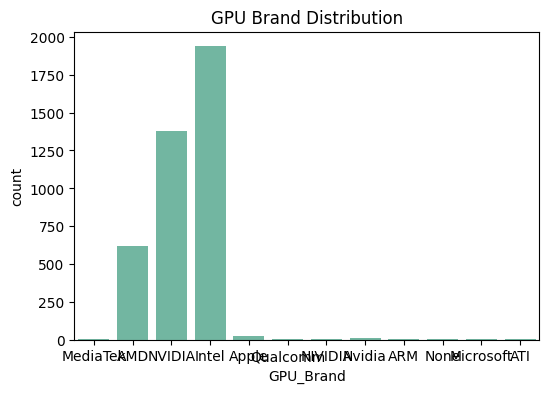

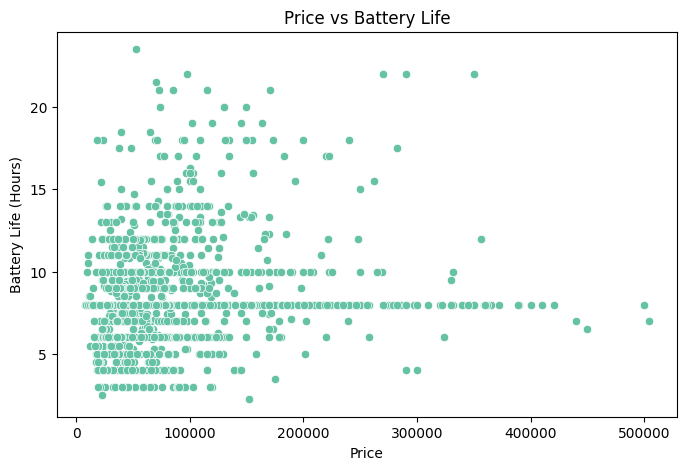

In [14]:
# Brand Distribution

print("\nTop 10 Brands:")
print(df['Brand'].value_counts().head(10))

plt.figure(figsize=(10, 6))
sns.countplot(
    y=df['Brand'],
    order=df['Brand'].value_counts().index[:10]
)
plt.title("Top 10 Laptop Brands")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()


# Price Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Laptop Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


# Processor Brand vs Price

plt.figure(figsize=(7, 5))
sns.boxplot(x='Processor_Brand', y='Price', data=df)
plt.title("Processor Brand vs Price")
plt.show()


# RAM vs Price

plt.figure(figsize=(7, 5))
sns.boxplot(x='RAM', y='Price', data=df)
plt.title("RAM vs Laptop Price")
plt.show()


# GPU Brand Distribution

plt.figure(figsize=(6, 4))
sns.countplot(x='GPU_Brand', data=df)
plt.title("GPU Brand Distribution")
plt.show()


# Price vs Battery Life

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Price', y='Battery_Life', data=df)
plt.title("Price vs Battery Life")
plt.xlabel("Price")
plt.ylabel("Battery Life (Hours)")
plt.show()

# Filters (User-Based Queries)

In [15]:
# Gaming Laptops

gaming_laptops = df[
    (df['GPU_Brand'] == 'NVIDIA') &
    (df['RAM'] >= 16)
]

print("\nGaming Laptops (NVIDIA + 16GB RAM):")
print(gaming_laptops[['Brand', 'Name', 'GPU', 'RAM', 'Price']].head())


# Budget Laptops

budget_laptops = df[df['Price'] < 40000]

print("\nBudget Laptops (Under 40,000):")
print(budget_laptops[['Brand', 'Name', 'RAM', 'Processor_Name', 'Price']].head())


# Long Battery Life Laptops

battery_laptops = df[df['Battery_Life'] >= 8]

print("\nLong Battery Life Laptops (8+ Hours):")
print(battery_laptops[['Brand', 'Name', 'Battery_Life', 'Price']].head())


Gaming Laptops (NVIDIA + 16GB RAM):
     Brand                                               Name  \
2     Dell  Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...   
10  Lenovo  Lenovo LOQ 15APH8 (82XT004JIN) Laptop (15.6 In...   
12    Acer  Acer Predator Helios Neo 16 PHN16-71 (NH.QLTSI...   
14    Acer  Acer Predator Helios Neo 16 PHN16-71 (NH.QLTSI...   
18    Acer  Acer Nitro V ANV15-51 (UN.QN8SI.001) Laptop (1...   

                           GPU  RAM   Price  
2   GeForce RTX 3050 GPU, 4 GB   16   78500  
10  GeForce RTX 4050 GPU, 6 GB   16   92990  
12  GeForce RTX 4050 GPU, 6 GB   16  104990  
14  GeForce RTX 4050 GPU, 6 GB   16  112980  
18  GeForce RTX 4050 GPU, 6 GB   16   77860  

Budget Laptops (Under 40,000):
     Brand                                               Name  RAM  \
0       HP  HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...    4   
1   Lenovo  Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....    8   
4  Infinix  Infinix Inbook Y2 Plus XL29 Laptop (15.6 I

# Save Cleaned Data

In [16]:
# save the cleaned Data

df.to_csv("/content/laptop.csv", index=False)
print("\nCleaned dataset saved as cleaned_laptops.csv")

print("\n--- Analysis Completed Successfully ---")


Cleaned dataset saved as cleaned_laptops.csv

--- Analysis Completed Successfully ---
